<a href="https://colab.research.google.com/github/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/magnification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
#
#  Copyright 2026 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:    Franck Vidal (UKRI-STFC)

![gVXR](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/img/Logo-transparent-small.png?raw=1)

# Magnification, SDD, SOD, ODD and inverse square law.

blablabla

![illustration](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/img/illustration.jpg?raw=1)



<div class="alert alert-block alert-warning">
    <b>Note:</b> Make sure the Python packages are already installed. See <a href="../README.md">README.md</a> in the root directory of the repository. If you are running this notebook from Google Colab, please run the cell below to install the required packages.
</div>

Install condacolab if needed

In [2]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q condacolab
    import condacolab
    condacolab.install()

Check if Conda is working well on Google Colab if needed

In [3]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import condacolab
    condacolab.check()

Install CIL using Conda on Google Colab if needed

In [4]:
if IN_COLAB:
    !conda install -y -c conda-forge -c https://software.repos.intel.com/python/conda -c ccpi cil=24.3.0 ipp=2021.12 tigre

Install other system packages and gVXR


In [ ]:
if IN_COLAB:
    !apt-get install libnvidia-gl-580
    !apt-get install \
        libxcb-res0 \
        libxcb-ewmh2 \
        libxcb-composite0 \
        libxcb-cursor0 \
        libxcb-xinerama0 \
        libxcb-keysyms1 \
        libxcb-icccm4 \
        libxcb-xkb1

    !pip install gvxr

## Aims of this session

1. Understand the notion of pixel size in the context of a cone-beam geometry and how the magnification affects it.
2. ~~.~~

![Screenshot of the 3D environment using K3D](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/output_data/magnification/k3d_screenshot-cropped.png?raw=1)

## Import packages

- `os` to create the output directory if needed
- `matplotlib` to show 2D images
- `SimpleITK` to load the DICOM file
- `gvxr` to simulate X-ray images
- `gvxr2json` to store details of a simulation in a JSON file
- Various `cil` packages for CT reconstruction

In [1]:
# import numpy as np # Who does not use Numpy?

import matplotlib.pyplot as plt # Plotting
plt.style.use('tableau-colorblind10')

#  CT simulation
from gvxrPython3.JSON2gVXRDataReader import *

# CT reconstruction
from cil.plugins.astra import FBP
from cil.io import TIFFWriter

from cil.processors import TransmissionAbsorptionConverter
from cil.utilities.display import show_geometry

/home/fpvidal/miniconda3/envs/gVXR-CIL-ICTMS2026/lib/python3.12/site-packages/cil/optimisation/operators/SparseFiniteDifferenceOperator.py:19: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  import scipy.sparse as sp


## Getting the data ready

Where to save the data.

In [3]:
output_path = "./output_data/magnification"

Read the simulated data with CIL

In [14]:
simulation_string_ID = "material_C2H3Cl-smaller_SDD"
# simulation_string_ID = "material_C2H3Cl-larger_SDD"
simulation_string_ID = "material_Al-smaller_SDD"
# simulation_string_ID = "material_Al-larger_SDD"
JSON_fname = os.path.join(output_path, simulation_string_ID + ".json")

reader = JSON2gVXRDataReader(JSON_fname)

data = reader.read()

[512, 512]
[0.06000000238418579, 0.06000000238418579]


In [15]:
print("data.geometry", data.geometry)

data.geometry 3D Cone-beam tomography
System configuration:
	Source position: [-40.,   0.,   0.]
	Rotation axis position: [-1.90734863e-07,  0.00000000e+00, -1.52587891e-06]
	Rotation axis direction: [ 0.,  0., -1.]
	Detector position: [10.,  0.,  0.]
	Detector direction x: [-0.,  1.,  0.]
	Detector direction y: [ 0.,  0., -1.]
Panel configuration:
	Number of pixels: [512 512]
	Pixel size: [0.06 0.06]
	Pixel origin: bottom-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1000
	Angles 0-9 in degrees: [0.  , 0.36, 0.72, 1.08, 1.44, 1.8 , 2.16, 2.52, 2.88, 3.24]
	Angles 990-999 in degrees: [356.4 , 356.76, 357.12, 357.48, 357.84, 358.2 , 358.56, 358.92, 359.28,
 359.64]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


Show the geometry in 3D

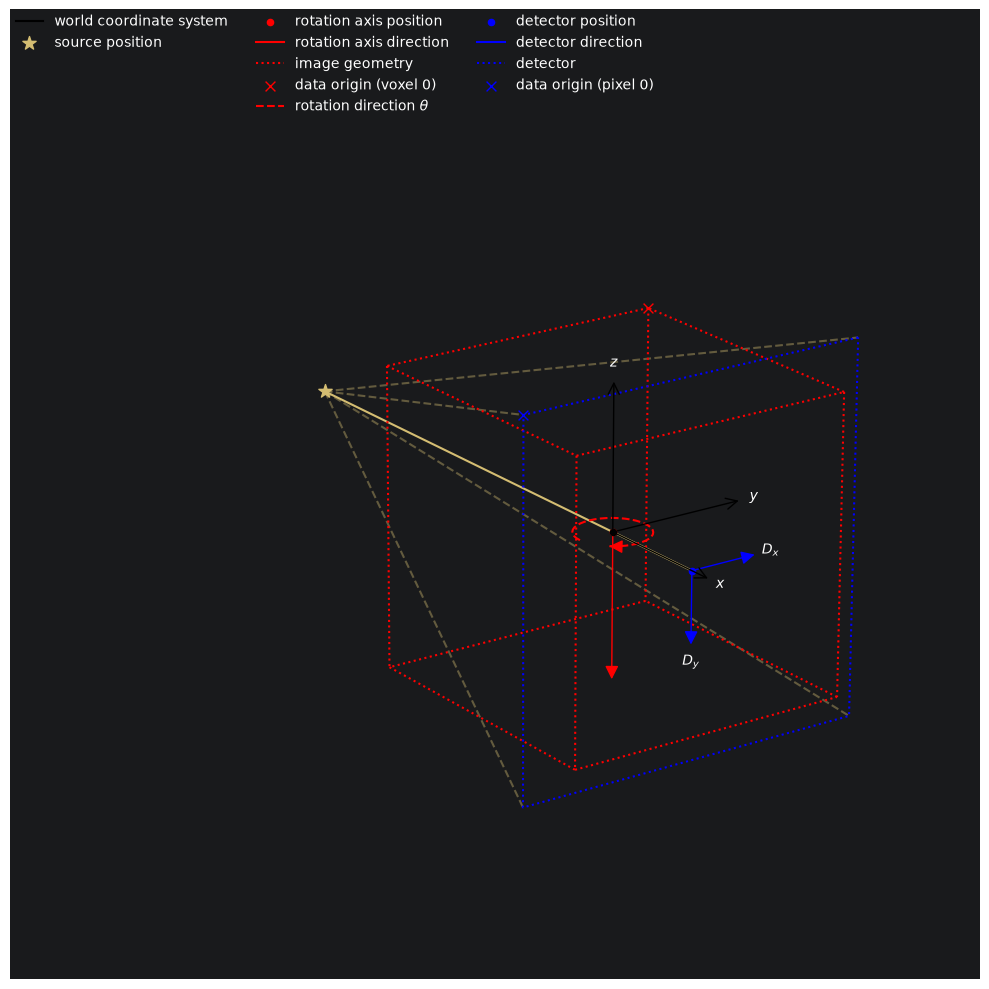

In [16]:
show_geometry(data.geometry)

Apply the minus log transformation (use use white_level=1.0 as the flat-field correction is already applied)


In [17]:
data_corr = TransmissionAbsorptionConverter(white_level=1.0)(data)

In [18]:
data_corr.reorder(order='astra')

We only want to reconstruct the slice in the middle of the volume

In [19]:
image_geometry = data_corr.geometry.get_ImageGeometry()

image_geometry.voxel_num_z = 1
print("Image geometry", image_geometry)

Image geometry Number of channels: 1
channel_spacing: 1.0
voxel_num : x512,y512,z1
voxel_size : x0.04800000167846678,y0.04800000167846678,z0.04800000167846678
center : x0,y0,z0



Perform the reconstruction with CIL

In [20]:
fbp = FBP(image_geometry, data_corr.geometry)
fbp.set_input(data_corr)
reconstruction = fbp.get_output()

Save the reconstructed CT images

In [21]:
writer = TIFFWriter(data=reconstruction,
                    file_name=os.path.join(output_path, simulation_string_ID),
                    compression="uint16")

writer.write()

Show the CT slice

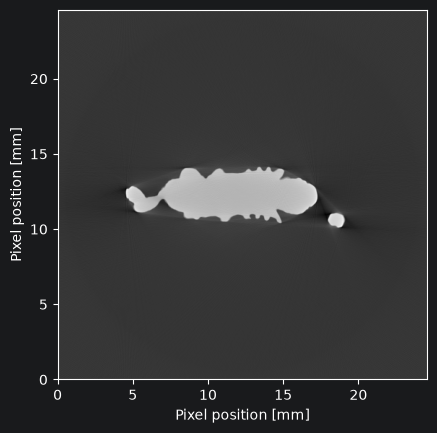

In [22]:
plt.figure()
plt.imshow(reconstruction.array,
    origin='upper',
    extent=(0.0, image_geometry.voxel_size_x * reconstruction.shape[1],
        0.0, image_geometry.voxel_size_y * reconstruction.shape[0]),
    cmap="gray"
)
plt.xlabel("Pixel position [mm]")
plt.ylabel("Pixel position [mm]")
plt.show()

---
## Task:

1. Restart the kernel.
2. Use aluminium instead of PVC for the sample material.
3. Re-run the notebook.
4. Run the reconstruction notebook.
5. Compare the two reconstructed images.
  - Can you see the effect of the noise (i.e. the SDD) on the reconstruction?
  - Can you see the cupping artefacts with the denser material?

---
## Optional tasks:

1. Add an aluminium filter to reduce beam hardening artefacts.
2. Reduce the number of photons much more.
3. Generate cone-beam artefacts.